<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/notebook2_content_hybrid_TODO_filled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 50%, #3949ab 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 2</h1>
  <h2 style="color:#c5cae9; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Контенттік Фильтрация жəне Гибридті Тəсілдер</h2>
  <p style="color:#e8eaf6; font-size:1em; margin:0;">TF-IDF · Пайдаланушы Профилі · Косинус Ұқсастық · Cascade · Weighted · Switching Hybrid</p>
</div>

## Кіріспе

**Контенттік фильтрация** — «пайдаланушы ұнатқан өнімдердің мазмұнына ұқсас өнімдерді ұсыну». CF-тен айырмасы — өнімнің мəтіндік, санаттық, тег жəне басқа ерекшеліктерін пайдаланады. Cold start мəселесін шешеді.

**Гибридті тəсілдер** əр əдістің əлсіздігін өзара толықтырады:
- **Weighted** — CF + CB скорларын α арқылы біріктіреді
- **Switching** — суық іске қосу жағдайында CB, əйтпесе CF пайдаланады
- **Cascade** — CF ұсыныстарын CB арқылы сорттайды
- **Feature Augmentation** — CB ерекшеліктерін CF-ке кіріс ретінде береді

## Оқу Мақсаттары

- TF-IDF + косинус ұқсастықпен item-item ұқсастық матрицасын жасай аласыз
- Пайдаланушы профилін рейтинг салмақтарымен құра аласыз
- Weighted, Switching, Cascade гибридті стратегиялары арасындағы айырмасын практикада байқайсыз
- Рейтинг санына байланысты адаптивті α (CF/CB тепе-теңдігі) жасай аласыз
- Leave-One-Out Precision@K бойынша əдістерді салыстыра аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


## 2-бөлім: Деректерді Жасау

In [2]:
N_USERS, N_ITEMS = 250, 180
N_GENRES = 7
GENRES   = ['Экшн','Комедия','Драма','Ғылыми фантастика','Романтика','Триллер','Анимация']

# Өнімнің жанры + мəтіндік ерекшеліктері
item_genre = np.zeros((N_ITEMS, N_GENRES))
for i in range(N_ITEMS):
    n_g = np.random.randint(1, 3)
    item_genre[i, np.random.choice(N_GENRES, n_g, replace=False)] = 1

# Мəтіндік сипаттама жасаймыз
genre_vocab = {
    'Экшн':              ['fight','hero','battle','war','explosion','adventure','chase'],
    'Комедия':           ['funny','laugh','humor','joke','silly','comedy','fun'],
    'Драма':             ['drama','family','emotion','love','relationship','tears','life'],
    'Ғылыми фантастика': ['space','future','robot','alien','quantum','technology','science'],
    'Романтика':         ['romance','heart','couple','kiss','wedding','sweet','love'],
    'Триллер':           ['mystery','dark','crime','detective','suspense','twist','thrill'],
    'Анимация':          ['cartoon','animated','character','kids','colorful','magic','fantasy'],
}

item_descriptions = []
for i in range(N_ITEMS):
    words = []
    for g in np.where(item_genre[i] > 0)[0]:
        words.extend(np.random.choice(genre_vocab[GENRES[g]], 8, replace=True).tolist())
    item_descriptions.append(' '.join(words))

# Рейтинг матрицасы
user_prefs  = np.random.dirichlet(np.ones(N_GENRES)*2, N_USERS)
true_affin  = user_prefs @ item_genre.T
true_affin  = 1 + 4*(true_affin - true_affin.min()) / (true_affin.max() - true_affin.min())

DENSITY = 0.07
mask    = np.random.binomial(1, DENSITY, (N_USERS, N_ITEMS)).astype(bool)
R       = np.where(mask, true_affin + np.random.randn(N_USERS, N_ITEMS)*0.3, 0.0)
R       = np.clip(R, 0, 5) * mask

print(f"{N_USERS} пайдаланушы, {N_ITEMS} өнім, {mask.mean():.2%} тығыздық")

250 пайдаланушы, 180 өнім, 7.05% тығыздық


## 3-бөлім: TF-IDF Ерекшелік Матрицасы

Əр өнімнің мəтіндік сипаттамасынан TF-IDF векторын жасаймыз. Бұл векторлар арқылы өнімдер арасындағы мазмұн ұқсастығын өлшейміз.

In [3]:
# ============================================================
### TODO ###
# TfidfVectorizer(max_features=80, ngram_range=(1,2))
# арқылы item_descriptions-ті векторизациялаңыз.
# item_tfidf — (N_ITEMS, 80) матрица.
# Item-item косинустық ұқсастық матрицасын есептеңіз.
# ============================================================
tfidf_vec  = TfidfVectorizer(max_features=80, ngram_range=(1,2))
item_tfidf = tfidf_vec.fit_transform(item_descriptions).toarray()

item_sim_matrix = cosine_similarity(item_tfidf)

print(f"TF-IDF матрица пішімі: {item_tfidf.shape}")
print(f"Item-Item ұқсастық матрица: {item_sim_matrix.shape}")
print(f"Орташа ұқсастық: {item_sim_matrix[~np.eye(N_ITEMS,dtype=bool)].mean():.4f}")

TF-IDF матрица пішімі: (180, 80)
Item-Item ұқсастық матрица: (180, 180)
Орташа ұқсастық: 0.1075


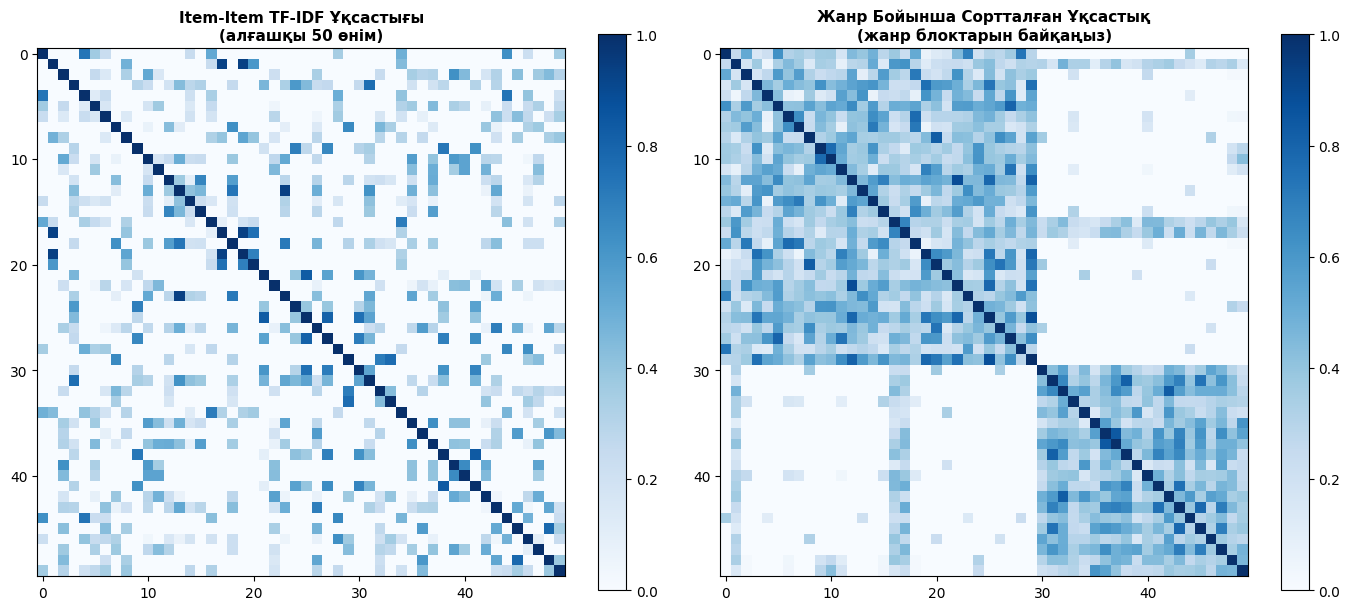

In [4]:
# Item-Item ұқсастық матрицасын жанр бойынша визуализациялаймыз
# Өнімдерді жанр бойынша сорттаймыз
primary_genre = np.argmax(item_genre, axis=1)
sort_idx      = np.argsort(primary_genre)

sim_sorted    = item_sim_matrix[np.ix_(sort_idx, sort_idx)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(item_sim_matrix[:50, :50], cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im1, ax=ax1)
ax1.set_title('Item-Item TF-IDF Ұқсастығы\n(алғашқы 50 өнім)',
              fontsize=11, fontweight='bold')

im2 = ax2.imshow(sim_sorted[:50, :50], cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax2)
ax2.set_title('Жанр Бойынша Сортталған Ұқсастық\n(жанр блоктарын байқаңыз)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 4-бөлім: Content-Based Ұсыным — Пайдаланушы Профилі

In [5]:
def build_user_profile(user_idx, R, item_features, use_weights=True):
    """
    Пайдаланушы профилін рейтинг-салмақты TF-IDF орташасы ретінде жасайды.
    use_weights=True: жоғары рейтингке жоғары салмақ
    """
    rated_mask = R[user_idx] > 0
    if rated_mask.sum() == 0:
        return np.zeros(item_features.shape[1])

    rated_items   = item_features[rated_mask]
    if use_weights:
        weights   = R[user_idx, rated_mask]
        weights   = weights / weights.sum()
        profile   = weights @ rated_items
    else:
        profile   = rated_items.mean(axis=0)

    return profile / (np.linalg.norm(profile) + 1e-10)

def content_recommend(user_idx, R, item_features, top_n=10):
    """
    Content-based ұсыным.
    """
    profile = build_user_profile(user_idx, R, item_features)
    scores  = cosine_similarity(profile.reshape(1,-1), item_features).flatten()
    unrated = np.where(R[user_idx] == 0)[0]
    top_idx = unrated[np.argsort(scores[unrated])[::-1][:top_n]]
    return top_idx, scores[top_idx]

print("build_user_profile() жəне content_recommend() анықталды.")

build_user_profile() жəне content_recommend() анықталды.


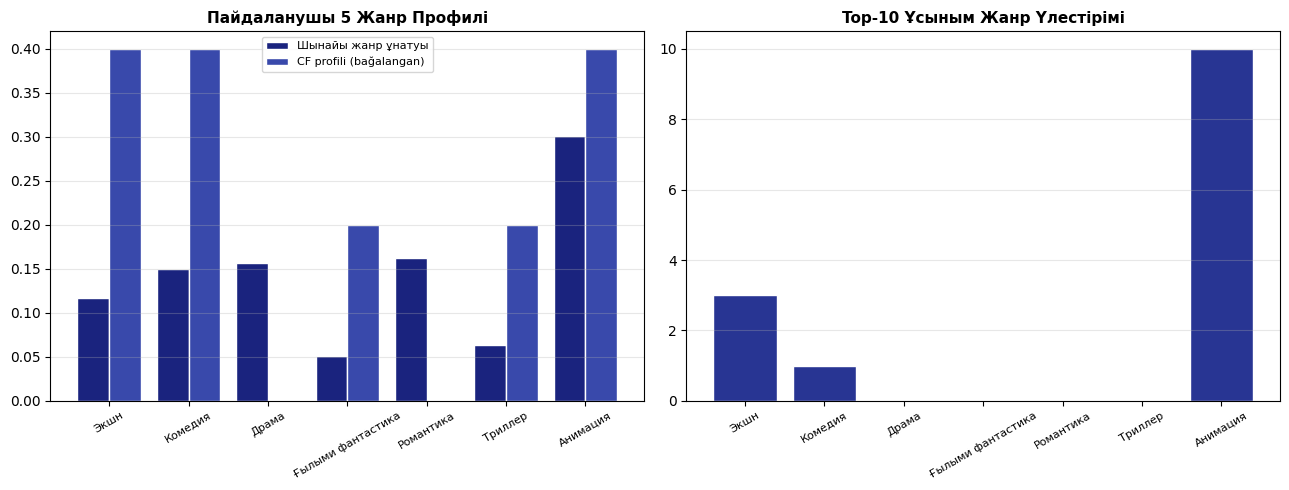

In [6]:
# Салмақты vs Салмақсыз профиль
TARGET_USER = 5

profile_w  = build_user_profile(TARGET_USER, R, item_tfidf, use_weights=True)
profile_uw = build_user_profile(TARGET_USER, R, item_tfidf, use_weights=False)

recs_w,  sc_w  = content_recommend(TARGET_USER, R, item_tfidf, top_n=10)
recs_uw, sc_uw = content_recommend(TARGET_USER, R,
    np.ones_like(item_tfidf), top_n=10)  # жанр-ғана профиль

# Пайдаланушы профилін жанр кеңістігінде бейнелейміз
genre_profile_w  = user_prefs[TARGET_USER]   # шынайы жанр ұнатуы
genre_profile_inferred = item_genre[np.where(R[TARGET_USER] > 0)[0]].mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(np.arange(N_GENRES) - 0.2, genre_profile_w,
        0.4, label='Шынайы жанр ұнатуы', color='#1a237e', edgecolor='white')
ax1.bar(np.arange(N_GENRES) + 0.2, genre_profile_inferred,
        0.4, label='CF profili (bağalangan)', color='#3949ab', edgecolor='white')
ax1.set_xticks(range(N_GENRES))
ax1.set_xticklabels(GENRES, rotation=30, fontsize=8)
ax1.set_title(f'Пайдаланушы {TARGET_USER} Жанр Профилі',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# Top-10 ұсыным — жанр үлестірімі
rec_genres = item_genre[recs_w].sum(axis=0)
ax2.bar(GENRES, rec_genres, color='#283593', edgecolor='white')
ax2.set_title(f'Top-10 Ұсыным Жанр Үлестірімі',
              fontsize=11, fontweight='bold')
ax2.set_xticklabels(GENRES, rotation=30, fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5-бөлім: Гибридті Стратегиялар

In [7]:
# CF болжам матрицасы — TruncatedSVD (K=20)
user_means = np.nanmean(np.where(R>0, R, np.nan), axis=1, keepdims=True)
R_c        = np.where(mask, R - user_means, 0.0)

svd_cf     = TruncatedSVD(n_components=20, random_state=42)
U_cf       = svd_cf.fit_transform(R_c)
R_cf_pred  = np.clip(
    U_cf @ np.diag(svd_cf.singular_values_) @ svd_cf.components_ + user_means,
    1, 5
)

print("CF матрицасы дайын (TruncatedSVD K=20).")

CF матрицасы дайын (TruncatedSVD K=20).


In [8]:
def get_cf_recs(user_idx, R_cf_pred, R_obs, top_n=10):
    """CF болжам матрицасынан ұсыным жасайды."""
    scores  = R_cf_pred[user_idx]
    unrated = np.where(R_obs[user_idx] == 0)[0]
    top     = unrated[np.argsort(scores[unrated])[::-1][:top_n]]
    return top, scores[top]

def weighted_hybrid(user_idx, R, R_cf_pred, item_features, alpha=0.6, top_n=10):
    """
    Weighted Hybrid: score = α·CF + (1-α)·CB
    Əр əдістің скорлары [0,1] диапазонына нормализацияланады.
    """
    cf_scores = R_cf_pred[user_idx].copy()
    mn, mx    = cf_scores.min(), cf_scores.max()
    cf_norm   = (cf_scores - mn) / (mx - mn + 1e-10)

    profile   = build_user_profile(user_idx, R, item_features)
    cb_scores = cosine_similarity(profile.reshape(1,-1), item_features).flatten()

    hybrid    = alpha * cf_norm + (1 - alpha) * cb_scores
    unrated   = np.where(R[user_idx] == 0)[0]
    top_idx   = unrated[np.argsort(hybrid[unrated])[::-1][:top_n]]
    return top_idx, hybrid[top_idx]

def switching_hybrid(user_idx, R, R_cf_pred, item_features,
                     min_ratings_for_cf=5, top_n=10):
    """
    Switching Hybrid:
    - Пайдаланушыда аз рейтинг → Content-based
    - Жеткілікті рейтинг → CF
    """
    n_rated = (R[user_idx] > 0).sum()
    if n_rated < min_ratings_for_cf:
        return content_recommend(user_idx, R, item_features, top_n), 'CB'
    else:
        return get_cf_recs(user_idx, R_cf_pred, R, top_n), 'CF'

def cascade_hybrid(user_idx, R, R_cf_pred, item_features,
                   top_n=10, cascade_pool=50):
    """
    Cascade Hybrid:
    1. CF-пен ірі пул (cascade_pool) ұсынымдары жасалады
    2. CB арқылы пул ішінен top_n сорттайды
    """
    # 1. CF пулы
    cf_recs, _  = get_cf_recs(user_idx, R_cf_pred, R, top_n=cascade_pool)

    # 2. CB арқылы пулды сорттаймыз
    profile     = build_user_profile(user_idx, R, item_features)
    cb_scores   = cosine_similarity(
        profile.reshape(1,-1), item_features[cf_recs]
    ).flatten()
    sorted_idx  = np.argsort(cb_scores)[::-1][:top_n]
    top_items   = cf_recs[sorted_idx]
    return top_items, cb_scores[sorted_idx]

print("Гибридті функциялар анықталды.")

Гибридті функциялар анықталды.


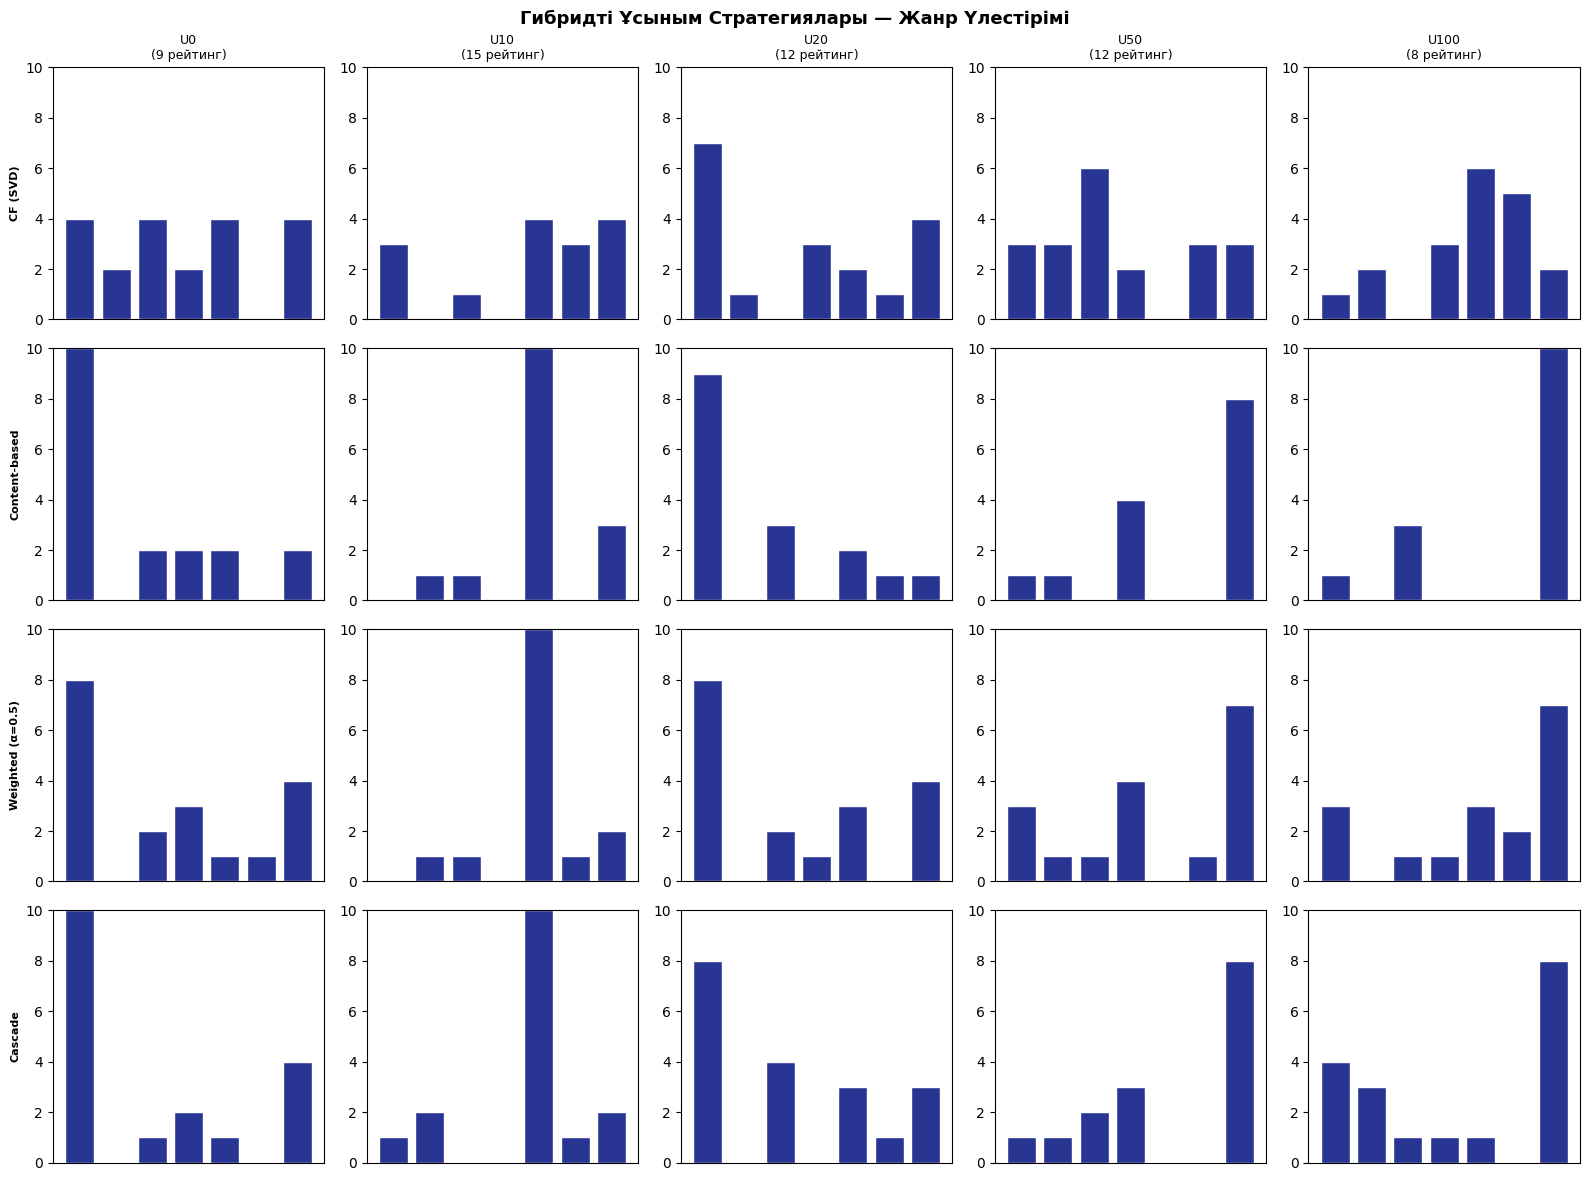

In [9]:
# ============================================================
### TODO ###
# 5 пайдаланушы үшін барлық 4 əдіс (CF, CB, Weighted, Cascade)
# ұсынымдарын алып, əр əдістің жанр үлестірімін
# 4×5 торда (əр əдіс — жол, əр пайдаланушы — баған) бейнелеңіз.
# ============================================================
test_users = [0, 10, 20, 50, 100]
method_labels = ['CF (SVD)', 'Content-based', 'Weighted (α=0.5)', 'Cascade']

fig, axes = plt.subplots(4, 5, figsize=(16, 12))
fig.suptitle('Гибридті Ұсыным Стратегиялары — Жанр Үлестірімі',
             fontsize=13, fontweight='bold')

for col, u in enumerate(test_users):
    # CF
    cf_r, _  = get_cf_recs(u, R_cf_pred, R, top_n=10)
    # CB
    cb_r, _  = content_recommend(u, R, item_tfidf, top_n=10)
    # Weighted
    wh_r, _  = weighted_hybrid(u, R, R_cf_pred, item_tfidf,
                                alpha=0.5, top_n=10)   # 0.5
    # Cascade
    ca_r, _  = cascade_hybrid(u, R, R_cf_pred, item_tfidf, top_n=10)   # R_cf_pred

    n_rated  = (R[u] > 0).sum()
    axes[0, col].set_title(f'U{u}\n({n_rated} рейтинг)', fontsize=9)

    for row, recs in enumerate([cf_r, cb_r, wh_r, ca_r]):
        genre_cnt = item_genre[recs].sum(axis=0) if len(recs) > 0 else np.zeros(N_GENRES)
        axes[row, col].bar(range(N_GENRES), genre_cnt,
                           color='#283593', edgecolor='white', width=0.8)
        axes[row, col].set_ylim(0, 10)
        axes[row, col].set_xticks([])
        if col == 0:
            axes[row, col].set_ylabel(method_labels[row], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 6-бөлім: Адаптивті α — Рейтинг Санына Байланысты

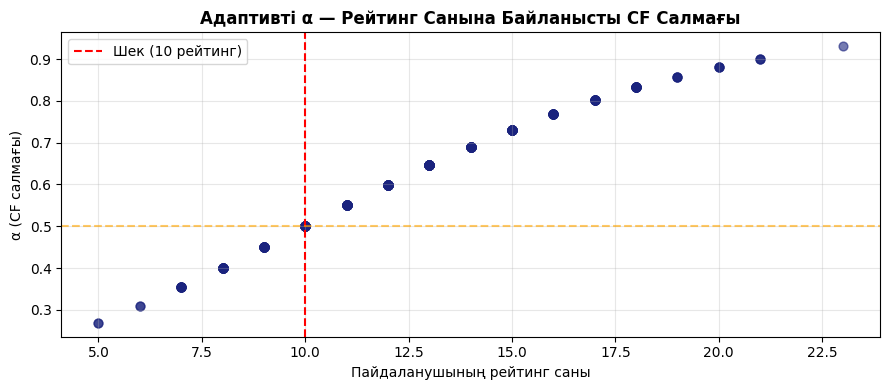

Орташа α: 0.618
α < 0.3 (CB басымды) пайдаланушылар: 2
α > 0.7 (CF басымды) пайдаланушылар: 74


In [10]:
# ============================================================
### TODO ###
# Пайдаланушының рейтинг санына байланысты α мəнін автоматты
# реттейтін adaptive_alpha() функциясын жазыңыз.
# Аз рейтинг → α кіші (CB басымды)
# Мол рейтинг → α үлкен (CF басымды)
# Логистикалық функция: α = 1/(1 + exp(-(n_rated - threshold)/scale))
# Əр пайдаланушы үшін α есептеп, scatter plot жасаңыз.
# ============================================================
def adaptive_alpha(n_rated, threshold=10, scale=5.0):
    """Рейтинг санына байланысты CF салмағы α."""
    return 1 / (1 + np.exp(-(n_rated - threshold) / scale))

user_rating_counts = (R > 0).sum(axis=1)
user_alphas        = adaptive_alpha(user_rating_counts)

plt.figure(figsize=(9, 4))
plt.scatter(user_rating_counts, user_alphas,
            alpha=0.6, color='#1a237e', s=40)
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.5,
            label='Шек (10 рейтинг)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
plt.title('Адаптивті α — Рейтинг Санына Байланысты CF Салмағы',
          fontsize=12, fontweight='bold')
plt.xlabel('Пайдаланушының рейтинг саны')
plt.ylabel('α (CF салмағы)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Орташа α: {user_alphas.mean():.3f}")
print(f"α < 0.3 (CB басымды) пайдаланушылар: {(user_alphas < 0.3).sum()}")
print(f"α > 0.7 (CF басымды) пайдаланушылар: {(user_alphas > 0.7).sum()}")

In [11]:
# LOO бағалау — Precision@K əр əдіс үшін
def lOO_precision_k(method_fn, R, n_eval=40, k=10, **kwargs):
    """Leave-One-Out Precision@K."""
    precisions = []
    for u in range(n_eval):
        seen = np.where(R[u] > 0)[0]
        if len(seen) < 3:
            continue
        held_out = [seen[-1]]
        R_loo    = R.copy()
        R_loo[u, held_out] = 0
        recs, _  = method_fn(u, R_loo, **kwargs)
        hits     = len(set(list(recs)[:k]) & set(held_out))
        precisions.append(hits / k)
    return np.mean(precisions)

# CF
p_cf = lOO_precision_k(
    lambda u, R_loo, **kw: get_cf_recs(u, R_cf_pred, R_loo, top_n=10),
    R, n_eval=40
)

# Content-based
p_cb = lOO_precision_k(
    lambda u, R_loo, **kw: content_recommend(u, R_loo, item_tfidf, top_n=10),
    R, n_eval=40
)

# Weighted hybrid α=0.5
p_wh = lOO_precision_k(
    lambda u, R_loo, **kw: weighted_hybrid(
        u, R_loo, R_cf_pred, item_tfidf, alpha=0.5, top_n=10
    ),
    R, n_eval=40
)

# Cascade
p_ca = lOO_precision_k(
    lambda u, R_loo, **kw: cascade_hybrid(
        u, R_loo, R_cf_pred, item_tfidf, top_n=10
    ),
    R, n_eval=40
)

print(f"Precision@10 (LOO):")
for name, val in [('CF (SVD)', p_cf), ('Content-based', p_cb),
                  ('Weighted α=0.5', p_wh), ('Cascade', p_ca)]:
    print(f"  {name:<20}: {val:.4f}")

Precision@10 (LOO):
  CF (SVD)            : 0.0150
  Content-based       : 0.0075
  Weighted α=0.5      : 0.0175
  Cascade             : 0.0125


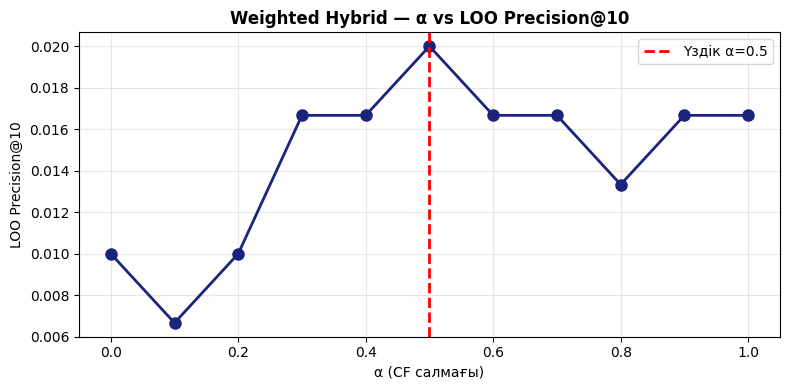

Үздік α=0.5, Precision@10=0.0200


In [12]:
# ============================================================
### TODO ###
# Əртүрлі α мəндері үшін Weighted Hybrid LOO Precision@K-ні
# есептеп, оңтайлы α-ны анықтаңыз.
# ============================================================
alpha_range = np.linspace(0, 1, 11)
prec_alpha  = []

for alpha_val in alpha_range:
    p = lOO_precision_k(
        lambda u, R_loo, a=alpha_val, **kw: weighted_hybrid(
            u, R_loo, R_cf_pred, item_tfidf, alpha=a, top_n=10
        ),
        R, n_eval=30
    )
    prec_alpha.append(p)

best_alpha = alpha_range[np.argmax(prec_alpha)]

plt.figure(figsize=(8, 4))
plt.plot(alpha_range, prec_alpha, 'o-', linewidth=2, color='#1a237e', markersize=8)   # alpha_range, prec_alpha
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=2,
            label=f'Үздік α={best_alpha:.1f}')
plt.title('Weighted Hybrid — α vs LOO Precision@10',
          fontsize=12, fontweight='bold')
plt.xlabel('α (CF салмағы)')
plt.ylabel('LOO Precision@10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Үздік α={best_alpha:.1f}, Precision@10={max(prec_alpha):.4f}")

## 7-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Content-based фильтрация суық іске қосу мəселесін шешеді дейміз. Бірақ Content-based-тің өз «суық іске қосу» мəселесі бар ма?

> Иә, Content-based әдісінің де өз cold start мәселесі бар. Егер жаңа пайдаланушы әлі ешбір өнімді бағаламаса, қарамаса немесе ұнатпаса, оның қызығушылық профилін құру қиын болады. Сонымен қатар жаңа өнімнің мәтіндік сипаттамасы, жанры, тегтері немесе басқа метадеректері болмаса, жүйе оның басқа өнімдерге ұқсастығын анықтай алмайды. Демек, Content-based тәсіл жаңа пайдаланушы және метадерегі жоқ жаңа өнім жағдайында қиындыққа тап болады.

**Сұрақ 2.** Cascade гибриді Weighted гибриді мен айырмасы неде? Қай жағдайда Cascade артықшылықты?

> Weighted гибридінде Collaborative Filtering және Content-based әдістерінің скорлары бір уақытта біріктіріледі:

score = α · CF + (1 − α) · CB

Ал Cascade гибридінде әдістер кезең-кезеңімен жұмыс істейді. Бірінші әдіс кандидат өнімдердің үлкен пулын таңдайды, ал екінші әдіс сол кандидаттарды қайта сұрыптайды. Мысалы, CF алдымен 50 өнім ұсынады, кейін Content-based әдіс олардың ішінен ең сәйкес 10 өнімді таңдайды.

Cascade бірінші модель кандидаттарды жақсы қамтитын, ал екінші модель нақты әрі сапалы қайта сұрыптау жасайтын жағдайда тиімді. Сонымен қатар екі әдістің скорларын бір шкалаға нормализациялау қиын болған кезде Cascade артықшылық береді.

**Сұрақ 3.** Адаптивті α неліктен тіркелген α-дан (мысалы, α=0.5) жақсы болуы мүмкін?

> Пайдаланушылардың рейтинг саны әртүрлі болғандықтан, барлық пайдаланушыға бірдей α қолдану тиімді болмауы мүмкін. Аз рейтинг берген пайдаланушы үшін Collaborative Filtering сенімсіз болады, сондықтан Content-based әдіске көбірек салмақ беру қажет. Ал рейтинг саны көп пайдаланушы үшін CF оның талғамын жақсырақ анықтайды, сондықтан CF салмағын арттыруға болады.

Адаптивті α әр пайдаланушының белсенділігіне байланысты CF және Content-based әдістерінің тепе-теңдігін автоматты түрде реттейді. Сол себепті ол тұрақты α-ға қарағанда жекелендірілген және икемдірек нәтиже береді.

**Сұрақ 4.** Өнімнің мəтіндік сипаттамасы болмаса Content-based-ке балама қандай ерекшеліктер пайдаланылады?

> Мәтіндік сипаттама болмаған жағдайда жанр, санат, тег, бренд, өндіруші, баға, түс, өлшем, шыққан жылы және техникалық сипаттамалар сияқты құрылымдық метадеректерді пайдалануға болады. Кескіндер үшін CNN немесе Vision Transformer арқылы алынған визуалдық embedding-тер, музыка үшін аудио ерекшеліктері, ал бейне үшін визуалдық және дыбыстық белгілер қолданылуы мүмкін. Сонымен қатар пайдаланушы енгізген тегтерді, сарапшы белгілерін және білім графтарын қолдануға болады.

## Қорытынды

Осы зертханада сіз TF-IDF + косинус ұқсастықпен item-item матрицасын жасадыңыз, рейтинг-салмақты пайдаланушы профилін құрдыңыз, Weighted, Switching жəне Cascade гибридті стратегияларын іске асырдыңыз, адаптивті α логистикалық функциямен жасап LOO бағалауда оңтайлы α тауып оны анықтадыңыз.

<div style="background-color:#e8eaf6; border-left:5px solid #1a237e; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 3 — Нейрожелі Автоэнкодерлер жəне Бағалау Метрикалары.
</div>